# Predicting Numerical Value

Some models predict a continuous variable. For example, can we predict a student's test score based on hours studied?

**Outcomes**:
- Interpret correlation strength and significance (p-value)
- Distinguish between correlation and causation
- Interpret a pairplot of correlation values

**Links:**
- [Correlation Simulation](correlation.html)
- [Correlation samples](correlation_samples.docx)
  - [Poll](https://docs.google.com/forms/d/e/1FAIpQLSdAzdeIGzL0F2j4xPqqmLLnq1bkcuslApHJhLw8ryXjkhHdTw/viewform?usp=publish-editor)
  - [Answers Spreadsheet](docs.google.com/spreadsheets/d/15DGDcSCIAMRfq71E-VJqOTNjM1knpSdsQP-Fu2rX-ZE)
- [Quizlet terms](https://quizlet.com/1127642197/ml04-predicting-numbers-flash-cards/?i=2up6jq&x=1jqt)


**Other Resources:**
- [Helpful video on correlation](https://www.youtube.com/watch?v=rijqfllOq6g)
- [Good discussion and examples of correlation](https://www.reddit.com/r/dataisbeautiful/comments/18p85yp/correlating_four_other_variables_with_a_states/?share_id=IsERBPtlNN-F0Bw9s0kSn)



## Correlation

A simple model for predicting numerical value is *correlation*. Correlation measures the strength *and* direction of a linear relationship between two continuous variables. 

Interpretation:
- Ranges from -1 to +1
  - +1 is perfect positive correlation (as one goes up, so does the other)
  - -1 is perfect negative correlation (as one goes up, the other goes down)
  - 0 is no correlation
  - Strong > 0.5, moderate > 0.25, weak around 0.2.

Correlation is not causation! Two variables may be correlated, but that does not mean one causes the other. There may be a third variable causing both, or it may be a coincidence. 

![Every person who confuses correlation with causation eventually dies](every_person_who_confuses.png)

## Measuring Error

In a classical approach to statistics, we measure error with p-values. 

**p-value**: the probability of observing the data if the null hypothesis is true
- A low p-value (<= 0.05) indicates that the observed effect is unlikely to be due to chance
- A high p-value (> 0.05) indicates that the observed effect could be due to chance

In newer ML approaches, we will measure error by splitting out data into test and training sets. After training our model, we will evaluate it using the test set. This will be covered in more detail in later modules.

A correlation has both:
- **Strength**: how closely the points fit a line
- **Statistical significance**: how likely the correlation is due to chance
  - p-value <= 0.05 is generally considered statistically significant


In [49]:
# Python Example of correlation
import pandas as pd
import numpy as np

df_meta = pd.read_csv('hwg_metadata.csv', skiprows=4)
df_measurements = pd.read_csv('hwg_measurements.csv', skiprows=0)

df_raw = pd.merge(df_meta, df_measurements, on='subject_id', how='inner')

# Convert gender to a is_male column
df_raw['is_male'] = np.where(df_raw['gender'] == 'male', 1, 0)

# Create heigh_m column
df_raw['height_m'] = df_raw['height_cm'] / 100

# Create bmi column
df_raw['bmi'] = df_raw['weight_kg'] / (df_raw['height_m'] ** 2)

# Keep only a few columns for easier analysis
df_raw = df_raw.drop(columns=['subject_id', 'gender'])
df_raw = df_raw[['height_cm', 'is_male', 'weight_kg', 'bmi',  'arm-length']]

df = df_raw.copy()

df


,height_cm,is_male,weight_kg,bmi,arm-length
0,160.00,0,92.40,36.093750,46.422310
1,175.75,0,102.80,33.281466,53.050766
2,174.80,1,106.90,34.986045,52.061996
3,181.50,1,111.80,33.938180,52.575706
4,161.60,0,93.00,35.612317,46.116558
...,...,...,...,...,...
1993,175.00,0,103.25,33.714286,52.452713
1994,169.50,1,103.90,36.163974,48.238476
1995,180.20,1,111.90,34.460416,52.979710
1996,168.00,1,102.60,36.352041,46.166344


In [50]:
# Calculate correlation between height and weight
correlation = df['height_cm'].corr(df['weight_kg'])

import scipy.stats as stats

# Calculate p-value
p_value = stats.pearsonr(df['height_cm'], df['weight_kg'])[1]

# Print the correlation
print(f"Correlation between height and weight: {correlation:.2f}")
print(f"P-value: {p_value:.2f}")

Correlation between height and weight: 0.55
P-value: 0.00


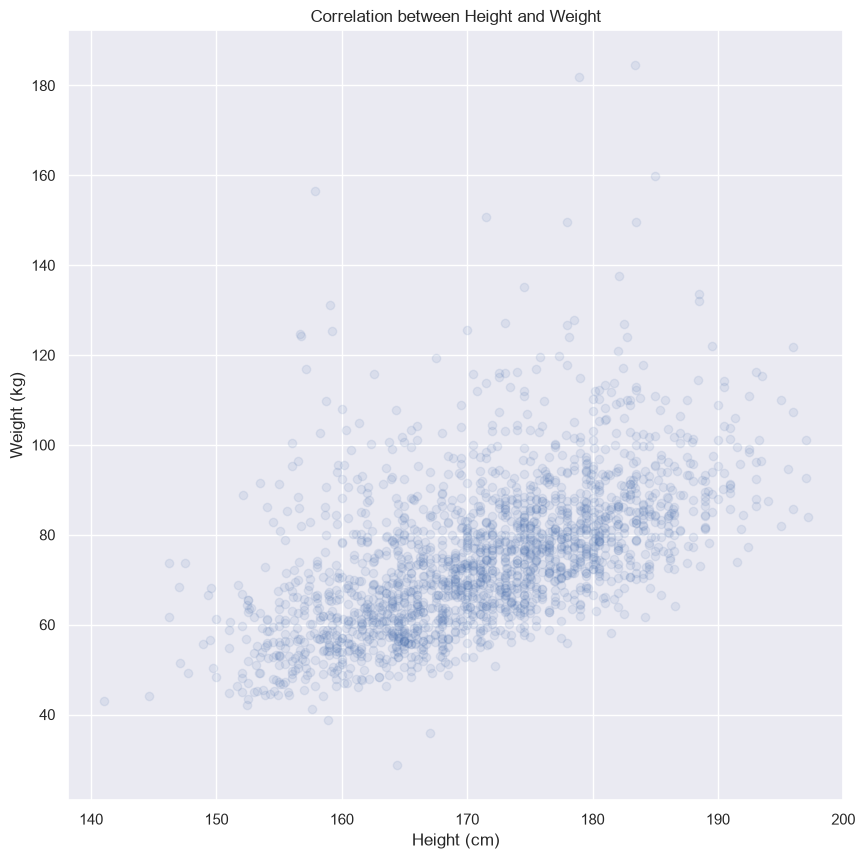

In [51]:
# Create a chart showing correlation between height and weight
import matplotlib.pyplot as plt

plt.scatter(df['height_cm'], df['weight_kg'], alpha=0.1)
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.title('Correlation between Height and Weight')
plt.show()

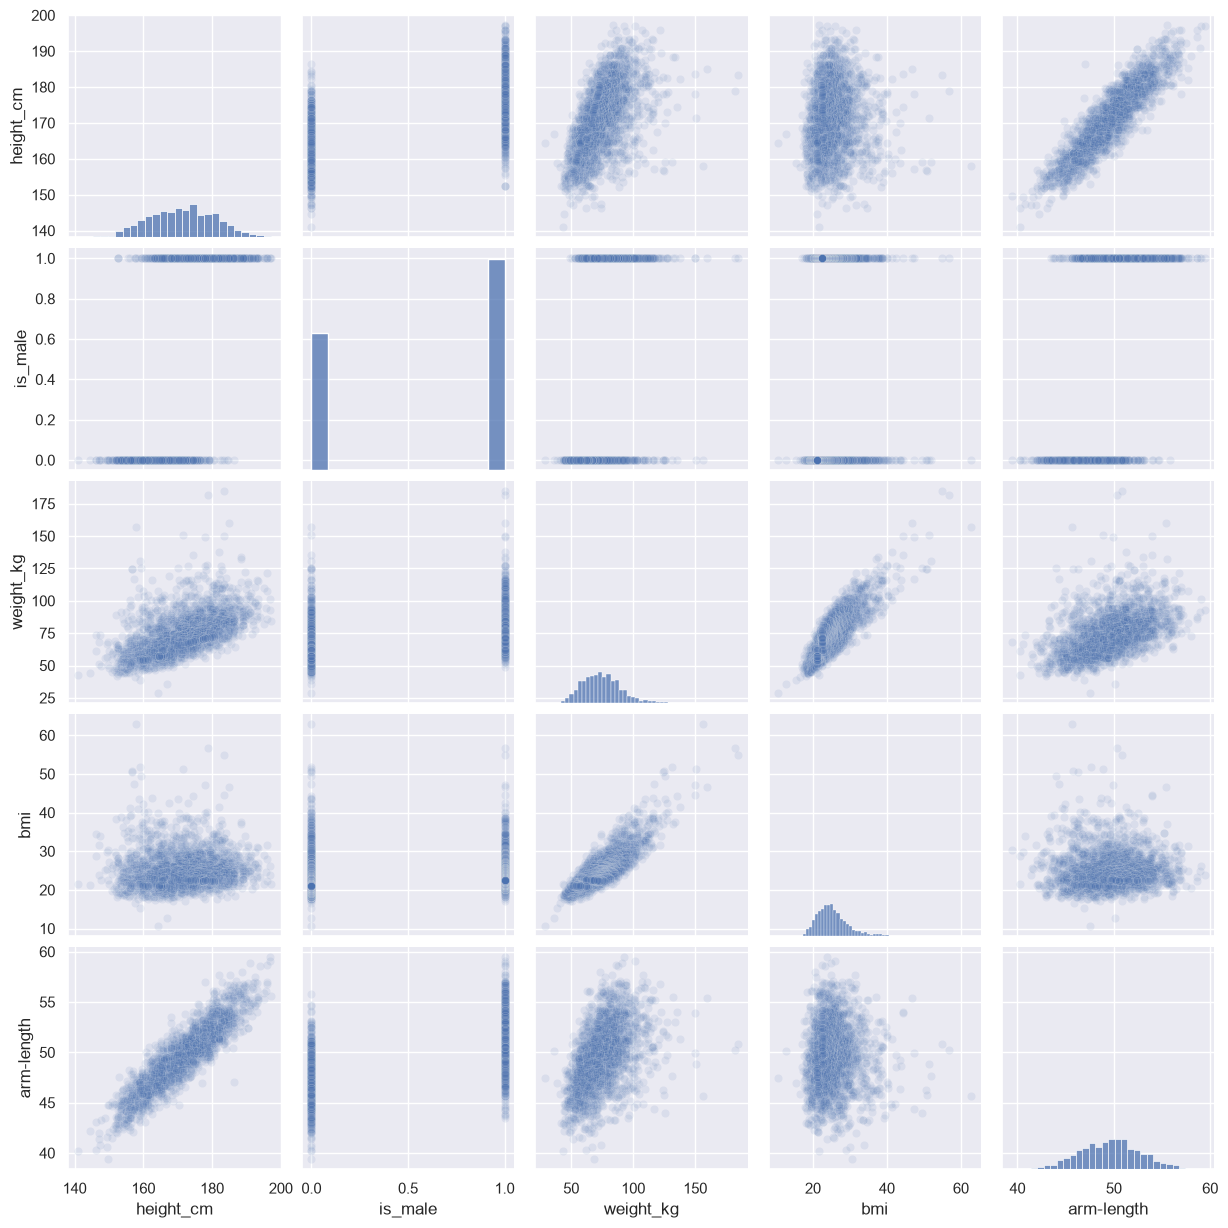

In [52]:
# Create a pairplot of all numeric columns, lowering alpha to 0.1 to reduce overplotting
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, diag_kind='hist', plot_kws={'alpha': 0.1})
sns.set(rc={'figure.figsize':(10,10)})
plt.show()

In [53]:
# Create a correlation matrix showing each numeric column's correlation with every other numeric column and the p-value


# Calculate the correlation matrix
corr_matrix = df.corr()

# Calculate the p-values
p_values = np.zeros((len(corr_matrix), len(corr_matrix)))
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        if i != j:
            p_values[i, j] = stats.pearsonr(df.iloc[:, i], df.iloc[:, j])[1]

# Create a DataFrame with the p-values
p_value_df = pd.DataFrame(p_values, index=corr_matrix.index, columns=corr_matrix.columns)

# Display the correlation matrix and p-values, rounded to 2 decimal places
corr_matrix = corr_matrix.round(3)
p_value_df = p_value_df.round(5)
print("Correlation Matrix:")
print(corr_matrix)
print("\nP-Values:")
print(p_value_df)

Correlation Matrix:
            height_cm  is_male  weight_kg    bmi  arm-length
height_cm       1.000    0.673      0.551  0.055       0.906
is_male         0.673    1.000      0.414  0.092       0.617
weight_kg       0.551    0.414      1.000  0.858       0.468
bmi             0.055    0.092      0.858  1.000       0.015
arm-length      0.906    0.617      0.468  0.015       1.000

P-Values:
            height_cm  is_male  weight_kg      bmi  arm-length
height_cm     0.00000  0.00000        0.0  0.01412     0.00000
is_male       0.00000  0.00000        0.0  0.00004     0.00000
weight_kg     0.00000  0.00000        0.0  0.00000     0.00000
bmi           0.01412  0.00004        0.0  0.00000     0.49687
arm-length    0.00000  0.00000        0.0  0.49687     0.00000
